# Klasifikasi dan Segmentasi Citra Pemutihan Terumbu Karang

In [1]:
# Mengaitkan Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from google.colab import userdata
import os

# Mengambil token hugging face
os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')

## 1. Dataset

In [3]:
# Install library datasets huggingface
!pip install datasets huggingface_hub -q

In [4]:
# Import library
import glob
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from datasets import load_dataset

- Dataset Coralscapes

In [5]:
# Load Dataset
coralscapes = load_dataset("EPFL-ECEO/coralscapes")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00009.parquet:   0%|          | 0.00/472M [00:00<?, ?B/s]

data/train-00001-of-00009.parquet:   0%|          | 0.00/448M [00:00<?, ?B/s]

data/train-00002-of-00009.parquet:   0%|          | 0.00/505M [00:00<?, ?B/s]

data/train-00003-of-00009.parquet:   0%|          | 0.00/444M [00:00<?, ?B/s]

...

data/test-00001-of-00003.parquet:   0%|          | 0.00/393M [00:00<?, ?B/s]

data/test-00002-of-00003.parquet:   0%|          | 0.00/358M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1517 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/166 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/392 [00:00<?, ? examples/s]

In [6]:
coralscapes

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 1517
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 166
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 392
    })
})

- Dataset NOAA

In [7]:
!unzip "/content/drive/MyDrive/[Penulisan Ilmiah]/dataset/noaa-coral.zip"
print("Ekstrak selesai!")

Streaming output truncated to the last 5000 lines.
  inflating: noaa-coral/train/CORAL/OAH-B005_2019_02_30075.PNG  
  inflating: noaa-coral/train/CORAL/OAH-B005_2019_03_30089.PNG  
  inflating: noaa-coral/train/CORAL/OAH-B005_2019_03_30090.PNG  
  inflating: noaa-coral/train/CORAL/OAH-B005_2019_04_30094.PNG  
  inflating: noaa-coral/train/CORAL/OAH-B005_2019_04_30096.PNG  
  inflating: noaa-coral/train/CORAL/OAH-B005_2019_04_30101.PNG  
  inflating: noaa-coral/train/CORAL/OAH-B005_2019_05_30102.PNG  
  inflating: noaa-coral/train/CORAL/OAH-B005_2019_05_30103.PNG  
  inflating: noaa-coral/train/CORAL/OAH-B005_2019_07_30122.PNG  
  inflating: noaa-coral/train/CORAL/OAH-B005_2019_07_30123.PNG  
  inflating: noaa-coral/train/CORAL/OAH-B005_2019_07_30125.PNG  
  inflating: noaa-coral/train/CORAL/OAH-B005_2019_09_30145.PNG  
  inflating: noaa-coral/train/CORAL/OAH-B005_2019_10_30156.PNG  
  inflating: noaa-coral/train/CORAL/OAH-B005_2019_10_30161.PNG  
  inflating: noaa-coral/train/CORAL/OAH

## 2. Data Understanding



- Dataset CoralScapes

In [8]:
# Melihat sample dataset
sample = coralscapes['train'][0]
sample

{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=2048x1024>,
 'label': <PIL.PngImagePlugin.PngImageFile image mode=L size=2048x1024>}

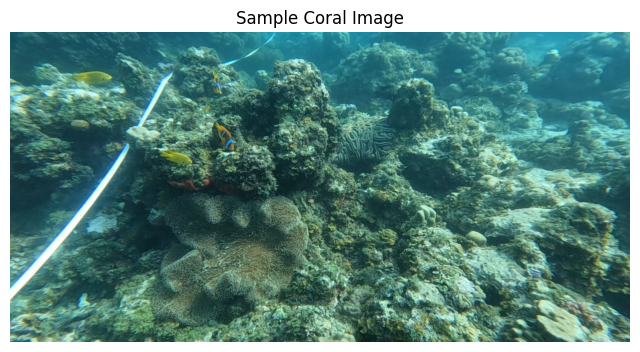

In [9]:
image = sample['image']

plt.figure(figsize=(8,6))
plt.imshow(image)
plt.title("Sample Coral Image")
plt.axis("off")
plt.show()

In [10]:
sample.keys()

dict_keys(['image', 'label'])

In [11]:
# Melihat jumlah data
print("Jumlah data train :", len(coralscapes['train']))

if 'test' in coralscapes:
    print("Jumlah data test :", len(coralscapes['test']))

Jumlah data train : 1517
Jumlah data test : 392


In [12]:
# Melihat size gambar
sizes = []

for i in range(20):
    img = coralscapes['train'][i]['image']
    sizes.append(img.size)

sizes[:10]

[(2048, 1024),
 (2048, 1024),
 (2048, 1024),
 (2048, 1024),
 (2048, 1024),
 (2048, 1024),
 (2048, 1024),
 (2048, 1024),
 (2048, 1024),
 (2048, 1024)]

In [13]:
# Distribusi resolusi gambar
widths = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

df_size = pd.DataFrame({
    'width': widths,
    'height': heights
})

df_size.describe()

,width,height
count,20.0,20.0
mean,2048.0,1024.0
std,0.0,0.0
min,2048.0,1024.0
25%,2048.0,1024.0
50%,2048.0,1024.0
75%,2048.0,1024.0
max,2048.0,1024.0


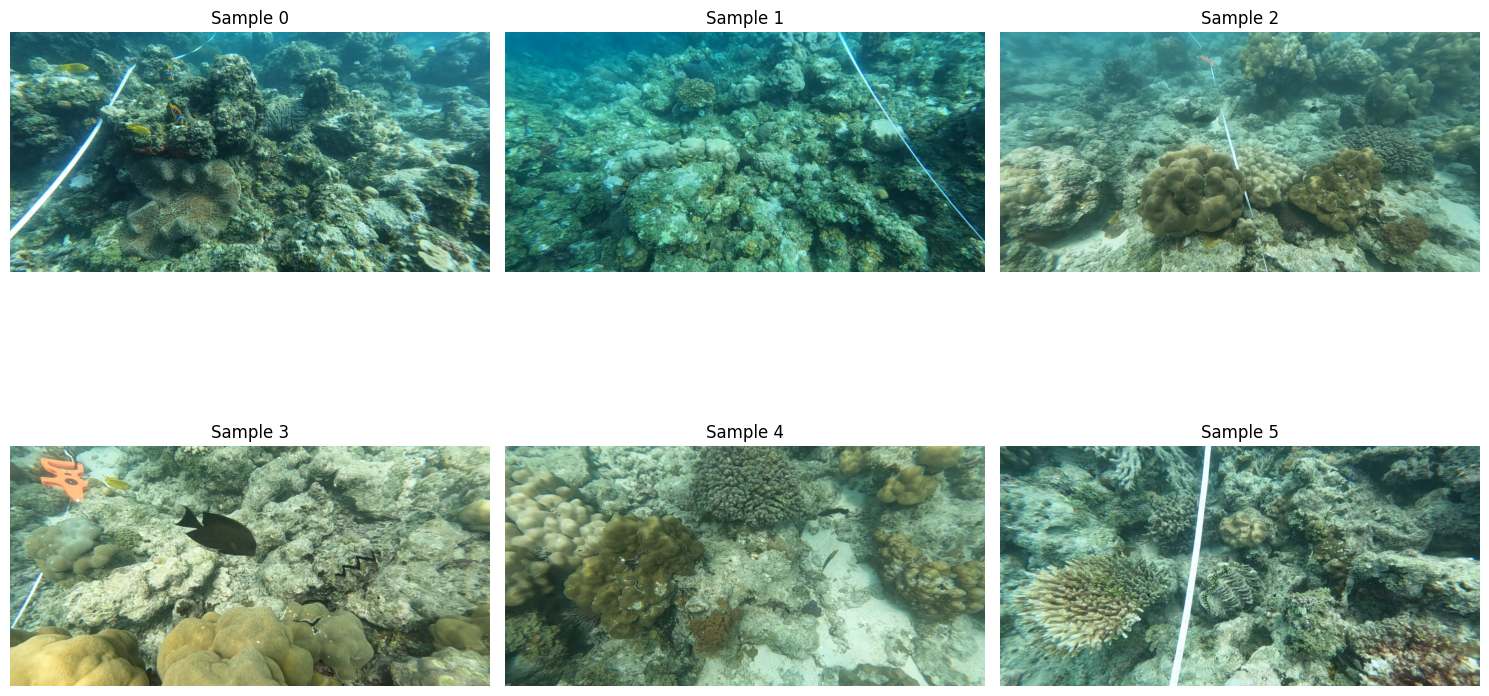

In [14]:
# Visualisasi beberapa sample
fig, axes = plt.subplots(2, 3, figsize=(15,10))

for idx, ax in enumerate(axes.flatten()):
    img = coralscapes['train'][idx]['image']
    ax.imshow(img)
    ax.set_title(f"Sample {idx}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [15]:
# Fitur dataset
coralscapes['train'].features

{'image': Image(mode=None, decode=True),
 'label': Image(mode=None, decode=True)}

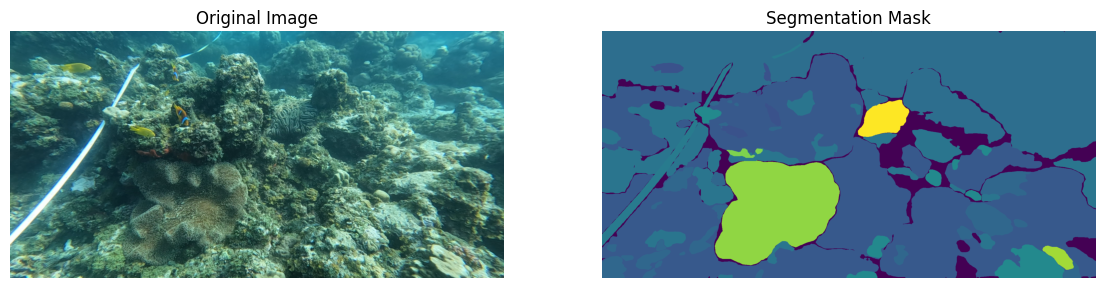

In [16]:
# Visualisasi Mask
sample = coralscapes['train'][0]

image = sample['image']
mask = sample['label']

fig, ax = plt.subplots(1, 2, figsize=(14,6))

ax[0].imshow(image)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(mask)
ax[1].set_title("Segmentation Mask")
ax[1].axis("off")

plt.show()

* Dataset NOAA

Eksplorasi Dataset NOAA sama seperti dataset CoralScapes diatas yang meliputi analisis struktur direktori, menghitung jumlah sampel per split (`train`, `val`, `test`), mengecek resolusi gambar, dan menampilkan sampel citra dari kelas `CORAL` dan `CORAL_BL`.

In [17]:
# Load Dataset
noaa = "/content/noaa-coral"

In [18]:
# Definisikan split dan kelas sesuai struktur direktori kamu
splits = ['train', 'val', 'test']
classes = ['CORAL', 'CORAL_BL']

In [19]:
data_distribution = []

print("Menghitung Data NOAA")
for split in splits:
    for cls in classes:
        # Mencari semua file gambar di dalam subfolder
        search_path = os.path.join(noaa, split, cls, "*.*")
        file_list = glob.glob(search_path)

        # Filter hanya file gambar (jpg, jpeg, png)
        image_list = [f for f in file_list if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        count = len(image_list)

        data_distribution.append({
            'Split': split,
            'Class': 'Healthy (CORAL)' if cls == 'CORAL' else 'Bleached (CORAL_BL)',
            'Count': count
        })
        print(f"[{split.upper()}] Kelas {cls}: {count} gambar")

df_dist = pd.DataFrame(data_distribution)

Menghitung Data NOAA
[TRAIN] Kelas CORAL: 4541 gambar
[TRAIN] Kelas CORAL_BL: 2751 gambar
[VAL] Kelas CORAL: 973 gambar
[VAL] Kelas CORAL_BL: 589 gambar
[TEST] Kelas CORAL: 974 gambar
[TEST] Kelas CORAL_BL: 591 gambar


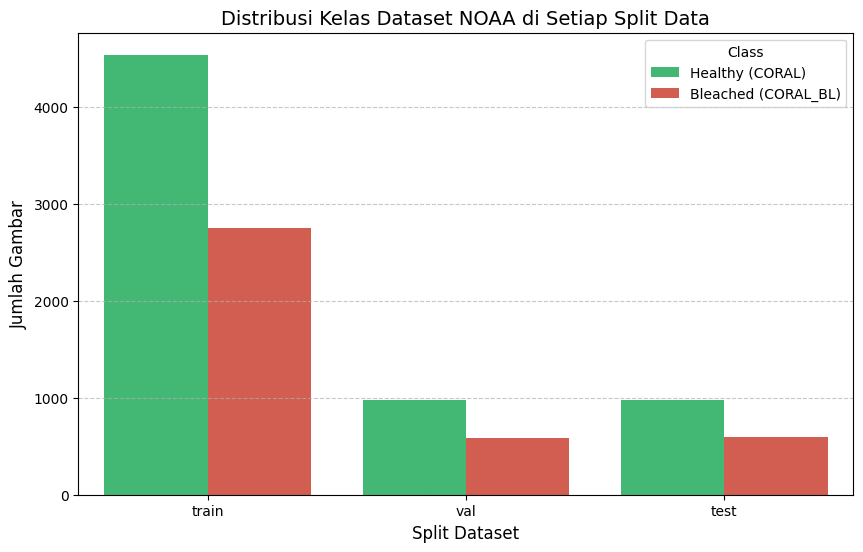

In [20]:
# Visualisasi Distribusi
plt.figure(figsize=(10, 6))
sns.barplot(data=df_dist, x='Split', y='Count', hue='Class', palette=['#2ECC71', '#E74C3C'])
plt.title('Distribusi Kelas Dataset NOAA di Setiap Split Data', fontsize=14)
plt.xlabel('Split Dataset', fontsize=12)
plt.ylabel('Jumlah Gambar', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [21]:
# Mengecek Resolusi Dataset NOAA
noaa_sizes = []
# Ambil 30 sampel acak dari folder train/CORAL untuk analisis dimensi awal
sample_paths = glob.glob(os.path.join(noaa, 'train', 'CORAL', "*.*"))[:30]

for p in sample_paths:
    if p.lower().endswith(('.png', '.jpg', '.jpeg')):
        with Image.open(p) as img:
            noaa_sizes.append(img.size)

df_noaa_size = pd.DataFrame({
    'Width': [s[0] for s in noaa_sizes],
    'Height': [s[1] for s in noaa_sizes]
})

print("Karakteristik Ukuran Gambar NOAA (Sampel):")
display(df_noaa_size.describe())

Karakteristik Ukuran Gambar NOAA (Sampel):


,Width,Height
count,30.0,30.0
mean,224.0,224.0
std,0.0,0.0
min,224.0,224.0
25%,224.0,224.0
50%,224.0,224.0
75%,224.0,224.0
max,224.0,224.0


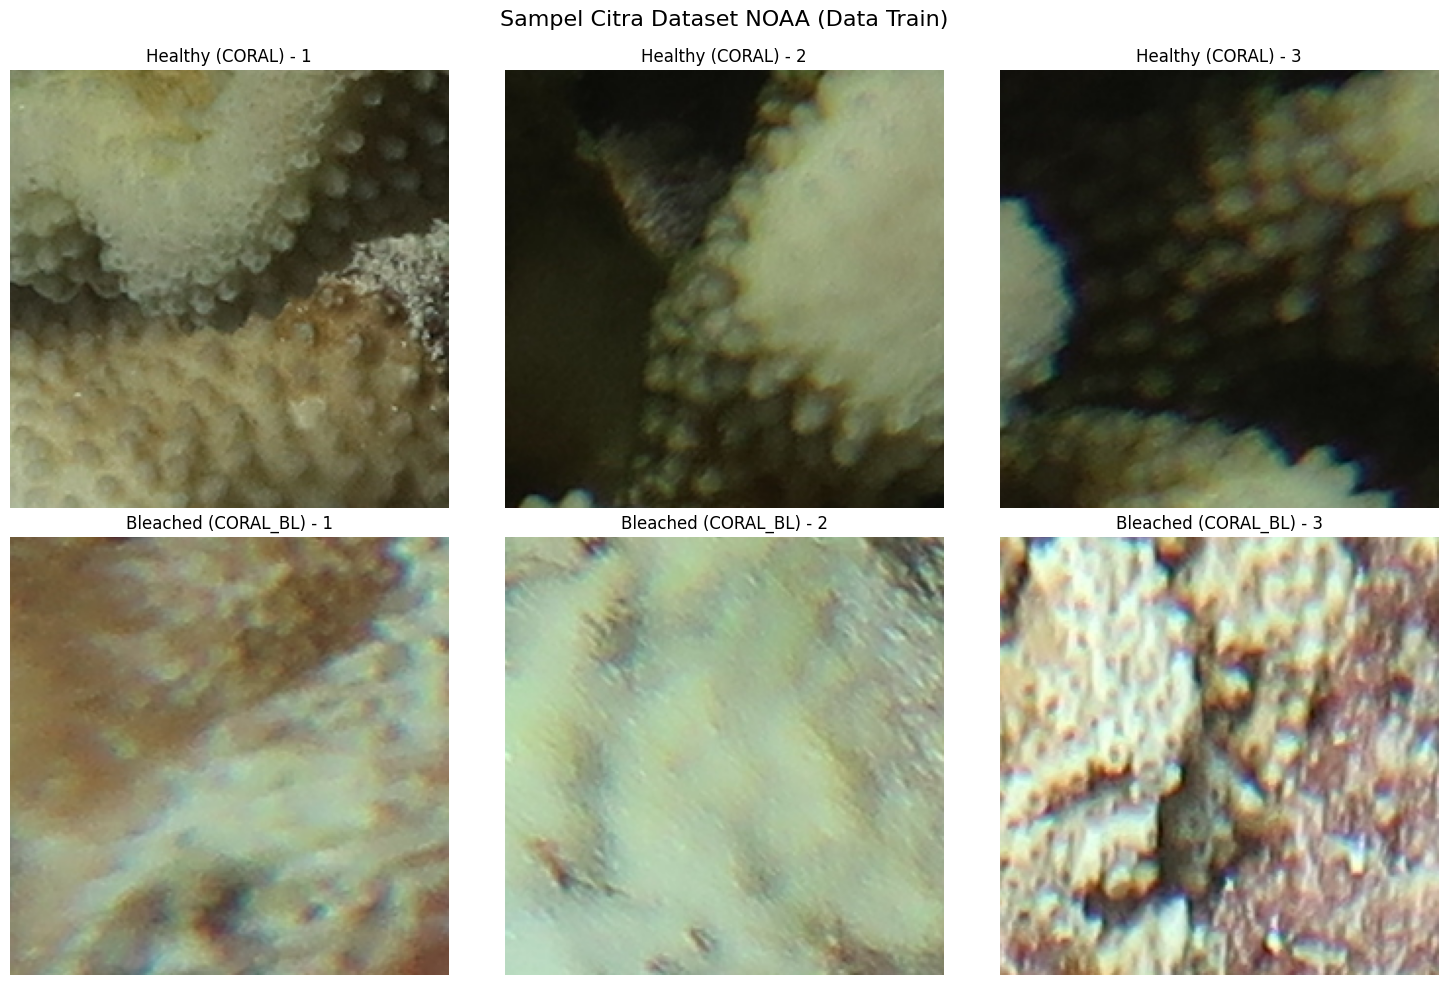

In [22]:
# Menampilkan sample
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Sampel Citra Dataset NOAA (Data Train)", fontsize=16)

# Ambil 3 gambar dari masing-masing kelas
healthy_train_samples = sorted(glob.glob(os.path.join(noaa, 'train', 'CORAL', "*.*")))[:3]
bleached_train_samples = sorted(glob.glob(os.path.join(noaa, 'train', 'CORAL_BL', "*.*")))[:3]

# Tampilkan Healthy (Baris Atas)
for i, img_path in enumerate(healthy_train_samples):
    img = Image.open(img_path)
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Healthy (CORAL) - {i+1}")
    axes[0, i].axis('off')

# Tampilkan Bleached (Baris Bawah)
for i, img_path in enumerate(bleached_samples := bleached_train_samples):
    img = Image.open(img_path)
    axes[1, i].imshow(img)
    axes[1, i].set_title(f"Bleached (CORAL_BL) - {i+1}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

## 3. Data Preparation

Tahapan ini meliputi:
1. **Load Data NOAA:** Memuat gambar dari folder `train`, `val`, dan `test/set` serta me-resize ke ukuran standar.
2. **Crop & Ekstrak Coralscapes (Stage 1):** Menggunakan *masking* untuk mengambil area terumbu karang saja.
3. **Integrasi & Splitting:** Membagi hasil crop Coralscapes dan menggabungkannya ke dalam split NOAA.
4. **Normalisasi:** Mengubah skala nilai piksel menjadi 0-1 (Float32).

In [23]:
# Import library yang dibutuhkan
import cv2
import numpy as np
from sklearn.model_selection import train_test_split

In [24]:
# Menentukan ukuran gambar
IMG_SIZE = (128, 128)

def load_noaa_split(base_path, split_name):
    X, y = [], []
    classes = {'CORAL': 0, 'CORAL_BL': 1} # 0 untuk Healthy, 1 untuk Bleached

    for cls_name, label in classes.items():
        folder_path = os.path.join(base_path, split_name, cls_name, "*.*")
        for img_path in glob.glob(folder_path):
            if img_path.lower().endswith(('.png', '.jpg', '.jpeg')):
                img = cv2.imread(img_path)
                if img is not None:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    img = cv2.resize(img, IMG_SIZE)
                    X.append(img)
                    y.append(label)
    return np.array(X), np.array(y)

print("Loading NOAA Dataset...")
X_noaa_train, y_noaa_train = load_noaa_split(noaa, 'train')
X_noaa_val, y_noaa_val = load_noaa_split(noaa, 'val')
X_noaa_test, y_noaa_test = load_noaa_split(noaa, 'test')

print(f"NOAA Train: {X_noaa_train.shape[0]} | Val: {X_noaa_val.shape[0]} | Test: {X_noaa_test.shape[0]}")

Loading NOAA Dataset...
NOAA Train: 7292 | Val: 1562 | Test: 1565


In [25]:
# Mapping id dataset CoralScapes
id2label = {
  1: "seagrass",
  2: "trash",
  3: "other coral dead",
  4: "other coral bleached",
  5: "sand",
  6: "other coral alive",
  7: "human",
  8: "transect tools",
  9: "fish",
  10: "algae covered substrate",
  11: "other animal",
  12: "unknown hard substrate",
  13: "background",
  14: "dark",
  15: "transect line",
  16: "massive/meandering bleached",
  17: "massive/meandering alive",
  18: "rubble",
  19: "branching bleached",
  20: "branching dead",
  21: "millepora",
  22: "branching alive",
  23: "massive/meandering dead",
  24: "clam",
  25: "acropora alive",
  26: "sea cucumber",
  27: "turbinaria",
  28: "table acropora alive",
  29: "sponge",
  30: "anemone",
  31: "pocillopora alive",
  32: "table acropora dead",
  33: "meandering bleached",
  34: "stylophora alive",
  35: "sea urchin",
  36: "meandering alive",
  37: "meandering dead",
  38: "crown of thorn",
  39: "dead clam"
}


In [26]:
# Menentukan Ukuran Gambar
IMG_SIZE = (128, 128)

def extract_crops_from_hf_split(hf_split, target_size=IMG_SIZE, max_per_class=1000):
    X_cs, y_cs = [], []
    bleached_ids = [4, 16, 19, 33]
    healthy_ids = [6, 17, 22, 25, 28, 31, 34, 36]

    count_bleached = 0
    count_healthy = 0

    for item in hf_split:
        if count_bleached >= max_per_class and count_healthy >= max_per_class:
            break

        img = np.array(item['image'])
        mask = np.array(item['label'])

        if count_bleached < max_per_class:
            for pixel_val in bleached_ids:
                binary_mask = (mask == pixel_val).astype(np.uint8) * 255
                contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                for cnt in contours:
                    if count_bleached >= max_per_class:
                        break
                    x, y, w, h = cv2.boundingRect(cnt)
                    if w > 40 and h > 40:
                        crop = cv2.resize(img[y:y+h, x:x+w], target_size)
                        X_cs.append(crop)
                        y_cs.append(1)
                        count_bleached += 1

        if count_healthy < max_per_class:
            for pixel_val in healthy_ids:
                binary_mask = (mask == pixel_val).astype(np.uint8) * 255
                contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                for cnt in contours:
                    if count_healthy >= max_per_class:
                        break
                    x, y, w, h = cv2.boundingRect(cnt)
                    if w > 40 and h > 40:
                        crop = cv2.resize(img[y:y+h, x:x+w], target_size)
                        X_cs.append(crop)
                        y_cs.append(0)
                        count_healthy += 1

    return np.array(X_cs), np.array(y_cs)

In [27]:
print("Mengekstrak crop dari Coralscapes TRAIN split...")
X_cs_train, y_cs_train = extract_crops_from_hf_split(coralscapes['train'])

print("Mengekstrak crop dari Coralscapes VALIDATION split...")
X_cs_val, y_cs_val = extract_crops_from_hf_split(coralscapes['validation'])

print("Mengekstrak crop dari Coralscapes TEST split...")
X_cs_test, y_cs_test = extract_crops_from_hf_split(coralscapes['test'])

# MENGGABUNGKAN DATASET CORALSCAPES & NOAA
print("\nMenggabungkan dataset...")
X_train_final = np.concatenate((X_noaa_train, X_cs_train), axis=0)
y_train_final = np.concatenate((y_noaa_train, y_cs_train), axis=0)

X_val_final = np.concatenate((X_noaa_val, X_cs_val), axis=0)
y_val_final = np.concatenate((y_noaa_val, y_cs_val), axis=0)

X_test_final = np.concatenate((X_noaa_test, X_cs_test), axis=0)
y_test_final = np.concatenate((y_noaa_test, y_cs_test), axis=0)

print(f"Total Train : {X_train_final.shape[0]} gambar")
print(f"Total Val   : {X_val_final.shape[0]} gambar")
print(f"Total Test  : {X_test_final.shape[0]} gambar")

Mengekstrak crop dari Coralscapes TRAIN split...
Mengekstrak crop dari Coralscapes VALIDATION split...
Mengekstrak crop dari Coralscapes TEST split...

Menggabungkan dataset...
Total Train : 8092 gambar
Total Val   : 2329 gambar
Total Test  : 2251 gambar


In [28]:
# Melihat berapa banyak data di masing-masing dataset
print(f"NOAA Train   : {X_noaa_train.shape[0]}")
print(f"CS Train     : {X_cs_train.shape[0]}")
print(f"NOAA Val     : {X_noaa_val.shape[0]}")
print(f"CS Val       : {X_cs_val.shape[0]}")
print(f"NOAA Test    : {X_noaa_test.shape[0]}")
print(f"CS Test      : {X_cs_test.shape[0]}")

NOAA Train   : 7292
CS Train     : 800
NOAA Val     : 1562
CS Val       : 767
NOAA Test    : 1565
CS Test      : 686


In [29]:
import gc

print("Membersihkan memori (Garbage Collection)...")

# Memastikan label dalam bentuk float32 (ukurannya sangat kecil, jadi aman untuk RAM)
y_train_final = y_train_final.astype('float32')
y_val_final = y_val_final.astype('float32')
y_test_final = y_test_final.astype('float32')

# Hapus pecahan variable yang tidak terpakai
try:
    del X_noaa_train, y_noaa_train, X_cs_train, y_cs_train
    del X_noaa_val, y_noaa_val, X_cs_val, y_cs_val
    del X_noaa_test, y_noaa_test, X_cs_test, y_cs_test
    # Hapus juga objek dataset coralscapes dari Hugging Face jika masih tersimpan di variabel tertentu
except NameError:
    pass

# Mengosongkan RAM
gc.collect()

print("Bentuk akhir data Train (uint8):", X_train_final.shape)
print("Data Preparation Selesai")

Membersihkan memori (Garbage Collection)...
Bentuk akhir data Train (uint8): (8092, 128, 128, 3)
Data Preparation Selesai


## 4. Modeling
Membangun arsitektur Custom Convolutional Neural Network (CNN) dari awal tanpa *transfer learning*.

**Karakteristik Model:**
1. **Layer Rescaling:** Mengubah skala piksel secara otomatis dari `0-255` (uint8) menjadi `0-1` (float32) saat proses *training*, sehingga sangat menghemat penggunaan memori RAM.
2. **Feature Extraction:** Terdiri dari 3 blok konvolusi. *Layer* konvolusi terakhir (`last_conv_layer`) disiapkan secara khusus agar nilainya bisa diekstrak oleh algoritma Grad-CAM nanti.
3. **Regularization:** Menggunakan `Dropout` sebesar 50% untuk mencegah *overfitting* pada klasifikasi.

In [111]:
from tensorflow.keras import layers, models, regularizers
import tensorflow as tf

In [112]:
# Membuat custom CNN
def build_custom_cnn(input_shape=(128, 128, 3)):
    model = models.Sequential([
        # Input layer
        layers.Input(shape=input_shape, name='input_layer'),

        # Layer normalisasi otomatis
        layers.Rescaling(1./255, name='rescaling_layer'),

        # Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(1e-5), name='conv2d_1'),
        layers.MaxPooling2D((2,2), name='maxpool_1'),

        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(1e-5), name='conv2d_2'),
        layers.MaxPooling2D((2,2), name='maxpool_2'),

        # Block 3 (Grad-CAM)
        layers.Conv2D(128, (3,3), activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(1e-5), name='last_conv_layer'),
        layers.MaxPooling2D((2,2), name='maxpool_3'),

        # Classification Head
        layers.Flatten(name='flatten'),
        layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-5), name='dense_1'),
        layers.Dropout(0.5, name='dropout'),

        # Output Layer (1 Neuron, Sigmoid untuk Binary Classification: 0 atau 1)
        layers.Dense(1, activation='sigmoid', name='output_layer')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Buat instansiasi model
cnn_model = build_custom_cnn()

# Tampilkan ringkasan arsitektur
cnn_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_layer (Rescaling)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling2D)        │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling2D)        │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv_layer (Conv2D)        │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_3 (MaxPooling2D)        │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,482,369 (32.36 MB)

 Trainable params: 8,482,369 (32.36 MB)

 Non-trainable params: 0 (0.00 B)

In [113]:
# Menambahkan Augmentasi Data
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

datagen_bleached = ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=20,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2]
)

bleached_idx = np.where(y_train_final == 1)[0]
healthy_idx = np.where(y_train_final == 0)[0]

def balanced_generator(X, y, bleached_idx, healthy_idx, batch_size=32):
    half = batch_size // 2
    while True:
        # Sample index secara random, tidak copy data
        b_idx = np.random.choice(bleached_idx, half)
        h_idx = np.random.choice(healthy_idx, half)

        X_b = X[b_idx].astype('float32')
        X_h = X[h_idx].astype('float32')

        # Augment bleached on-the-fly
        for i in range(len(X_b)):
            X_b[i] = datagen_bleached.random_transform(X_b[i])

        X_batch = np.concatenate([X_b, X_h])
        y_batch = np.concatenate([y[b_idx], y[h_idx]])

        idx = np.random.permutation(batch_size)
        yield X_batch[idx], y_batch[idx]

train_gen = balanced_generator(X_train_final, y_train_final, bleached_idx, healthy_idx)
steps = len(X_train_final) // 32

In [114]:
from sklearn.utils import resample

# Balance val set supaya loss-nya stabil
idx_h = np.where(y_val_final == 0)[0]
idx_b = np.where(y_val_final == 1)[0]

# Undersample healthy di val supaya 1:1
idx_h_down = resample(idx_h, n_samples=len(idx_b), random_state=42)
idx_val_balanced = np.concatenate([idx_h_down, idx_b])
np.random.shuffle(idx_val_balanced)

X_val_balanced = X_val_final[idx_val_balanced]
y_val_balanced = y_val_final[idx_val_balanced]

print(f"Val Healthy : {(y_val_balanced==0).sum()}")
print(f"Val Bleached: {(y_val_balanced==1).sum()}")

Val Healthy : 956
Val Bleached: 956


In [115]:
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("Memulai proses training model...")

# Tentukan parameter training
EPOCHS = 20
BATCH_SIZE = 32

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

# menggunakan class_weight untuk mengatasi imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train_final
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

history = cnn_model.fit(
    train_gen,
    steps_per_epoch=steps,
    validation_data=(X_val_balanced, y_val_balanced),  # <-- ganti ini
    epochs=20,
    callbacks=callbacks
)

print("Proses training selesai!")

Memulai proses training model...
Epoch 1/20
252/252 ━━━━━━━━━━━━━━━━━━━━ 32s 109ms/step - accuracy: 0.7882 - loss: 0.4638 - val_accuracy: 0.7286 - val_loss: 0.5720 - learning_rate: 0.0010
Epoch 2/20
252/252 ━━━━━━━━━━━━━━━━━━━━ 25s 99ms/step - accuracy: 0.8227 - loss: 0.4090 - val_accuracy: 0.7965 - val_loss: 0.4569 - learning_rate: 0.0010
Epoch 3/20
252/252 ━━━━━━━━━━━━━━━━━━━━ 24s 97ms/step - accuracy: 0.8243 - loss: 0.4017 - val_accuracy: 0.8075 - val_loss: 0.4319 - learning_rate: 0.0010
Epoch 4/20
252/252 ━━━━━━━━━━━━━━━━━━━━ 23s 93ms/step - accuracy: 0.8348 - loss: 0.3900 - val_accuracy: 0.7871 - val_loss: 0.4689 - learning_rate: 0.0010
Epoch 5/20
252/252 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.8465 - loss: 0.3759
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
252/252 ━━━━━━━━━━━━━━━━━━━━ 25s 99ms/step - accuracy: 0.8416 - loss: 0.3797 - val_accuracy: 0.8065 - val_loss: 0.4408 - learning_rate: 0.0010
Epoch 6/20
252/252 ━━━━━━━━━━━━━━━━━━━━ 24s 

## 5. Evaluation
Mengevaluasi performa model secara **kuantitatif** (Akurasi, Presisi, Recall dengan menggunakan *Classification Report* & *Confusion Matrix*) dan secara **kualitatif** (*Explainable AI* menggunakan Grad-CAM untuk melihat fokus keputusan model).

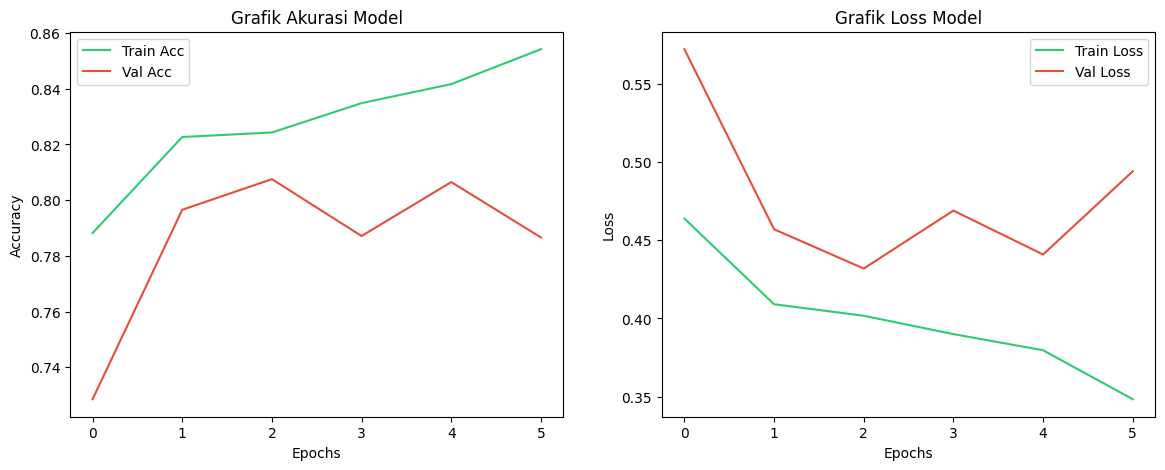

In [116]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. Plot Kurva Accuracy & Loss
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(history.history['accuracy'], label='Train Acc', color='#2ECC71')
ax[0].plot(history.history['val_accuracy'], label='Val Acc', color='#E74C3C')
ax[0].set_title('Grafik Akurasi Model')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')
ax[0].legend()

ax[1].plot(history.history['loss'], label='Train Loss', color='#2ECC71')
ax[1].plot(history.history['val_loss'], label='Val Loss', color='#E74C3C')
ax[1].set_title('Grafik Loss Model')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].legend()
plt.show()

In [117]:
# 2. Evaluasi menggunakan Data Test
print("\nEvaluasi pada Data Test")
test_loss, test_acc = cnn_model.evaluate(X_test_final, y_test_final, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%\n")


Evaluasi pada Data Test
Test Accuracy: 81.52%



In [118]:
# 3. Prediksi Data Test
y_pred_prob = cnn_model.predict(X_test_final)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


Classification Report:
              precision    recall  f1-score   support

     Healthy       0.86      0.84      0.85      1374
    Bleached       0.75      0.78      0.77       877

    accuracy                           0.82      2251
   macro avg       0.81      0.81      0.81      2251
weighted avg       0.82      0.82      0.82      2251



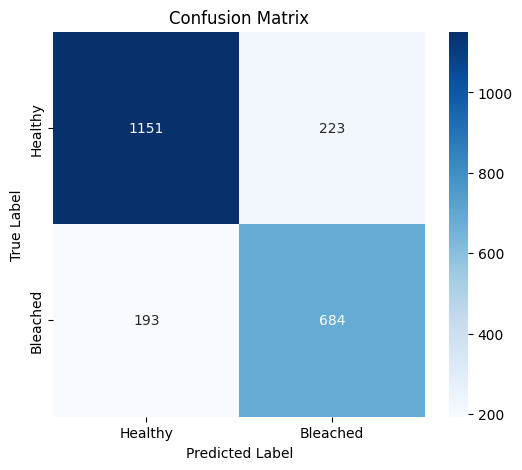

In [119]:
# 4. Classification Report & Confusion Matrix
print("Classification Report:")
print(classification_report(y_test_final, y_pred, target_names=['Healthy', 'Bleached']))

cm = confusion_matrix(y_test_final, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Bleached'],
            yticklabels=['Healthy', 'Bleached'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

Dibawah ini visualisasi metode GRAD-CAM untuk mencari tahu bagian gambar mana yang paling berpengaruh terhadap keputusan model

In [120]:
# Import library untuk GRAD-CAM
import tensorflow as tf
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt

In [121]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    img_array = tf.cast(img_array, tf.float32)

    # Cari index last_conv_layer
    layer_names = [l.name for l in model.layers]
    conv_idx = layer_names.index(last_conv_layer_name)

    # Split layers manual berdasarkan index
    pre_conv_layers = model.layers[:conv_idx + 1]   # sampai last_conv_layer (inklusif)
    post_conv_layers = model.layers[conv_idx + 1:]  # sisanya

    with tf.GradientTape() as tape:
        # Forward pass sampai conv layer
        x = img_array
        for layer in pre_conv_layers:
            x = layer(x)
        conv_output = x
        tape.watch(conv_output)

        # Forward pass sisa layer
        for layer in post_conv_layers:
            x = layer(x)
        preds = x

        class_channel = preds[:, 0]

    grads = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    heatmap = conv_output[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

In [122]:
def visualize_gradcam(index):
    img = X_test_final[index]
    true_label = int(y_test_final[index])

    # Tambahkan dimensi batch dan cast ke float32 untuk tf.GradientTape
    img_array = np.expand_dims(img, axis=0)
    img_tensor = tf.cast(img_array, tf.float32)

    # Dapatkan prediksi probabilitas
    pred_prob = cnn_model.predict(img_tensor, verbose=0)[0][0]
    pred_label = 1 if pred_prob > 0.5 else 0

    # Buat Heatmap
    heatmap = make_gradcam_heatmap(img_tensor, cnn_model, 'last_conv_layer')

    # Resize heatmap ke ukuran gambar asli
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_resized = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

    # Gabungkan dengan gambar asli (Superimposed)
    img_uint8 = np.uint8(img)
    superimposed_img = cv2.addWeighted(heatmap_color, 0.4, img_uint8, 0.6, 0)

    # Plotting
    str_true = 'Bleached' if true_label==1 else 'Healthy'
    str_pred = 'Bleached' if pred_label==1 else 'Healthy'

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"True: {str_true} | Pred: {str_pred} (Prob: {pred_prob:.4f})", fontsize=14)

    ax[0].imshow(img_uint8)
    ax[0].set_title("Original Image")
    ax[0].axis('off')

    ax[1].imshow(heatmap_color)
    ax[1].set_title("Grad-CAM Heatmap")
    ax[1].axis('off')

    ax[2].imshow(superimposed_img)
    ax[2].set_title("Superimposed")
    ax[2].axis('off')

    plt.show()

Menampilkan Grad-CAM untuk sampel acak dari Data Test...


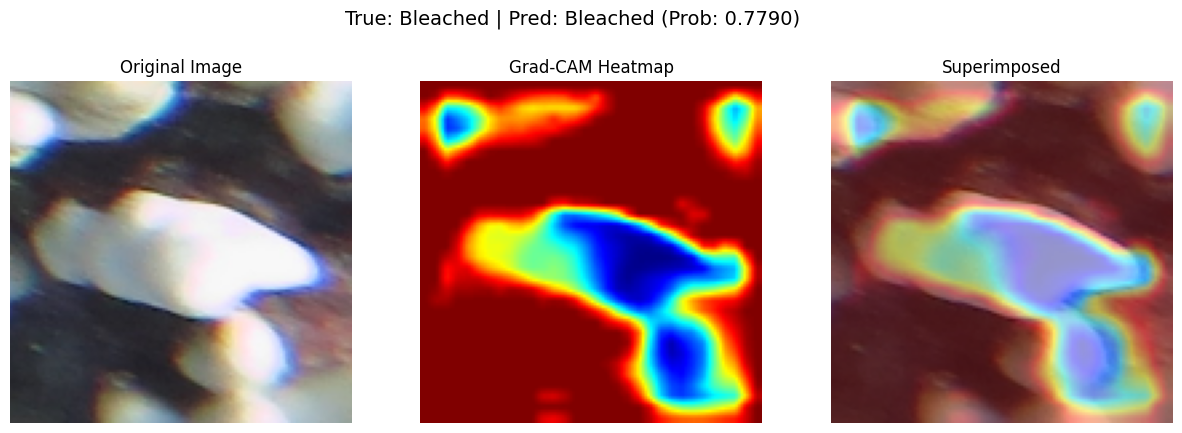

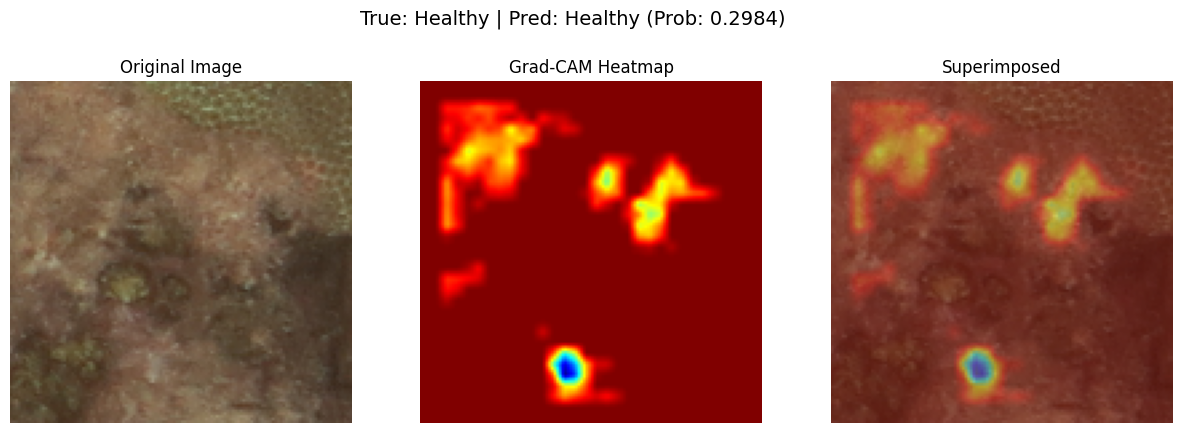

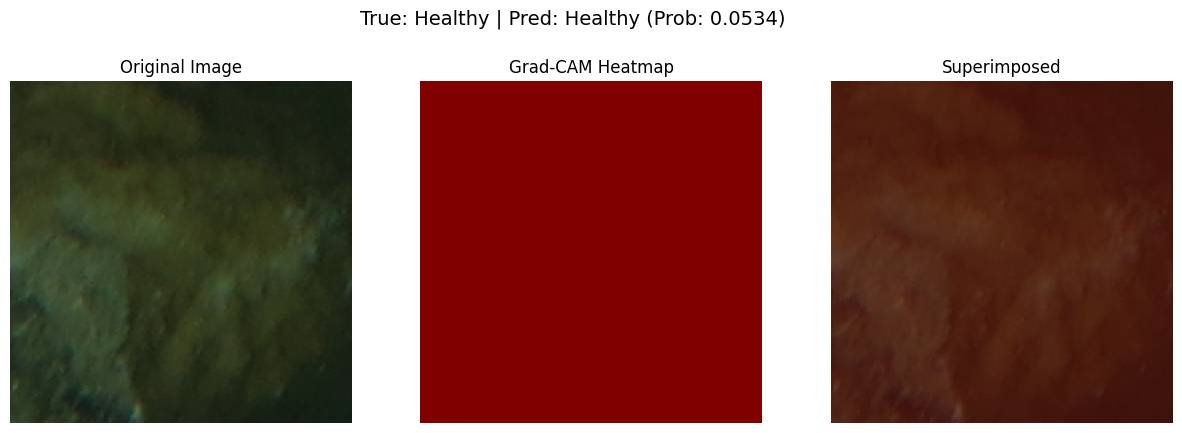

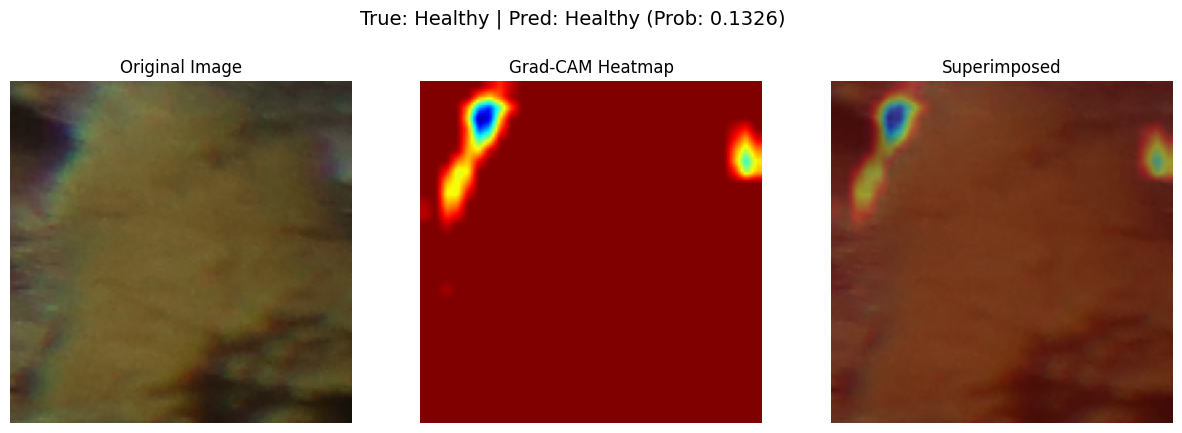

In [123]:
# menguji pada 4 gambar
print("Menampilkan Grad-CAM untuk sampel acak dari Data Test...")
for _ in range(4):
    random_idx = random.randint(0, len(X_test_final) - 1)
    visualize_gradcam(random_idx)

Estimasi pemutihan terumbu karang berdasarkan warna di piksel gambar

In [124]:
# Fungsi estimasi bleaching
def estimate_bleaching_percentage(img):
    """
    Estimasi persentase area bleaching berdasarkan warna putih/pucat.
    img: numpy array (128, 128, 3) uint8, RGB
    """
    # Konversi ke HSV
    img_hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

    # Threshold warna putih/pucat (low saturation, high value)
    lower = np.array([0, 0, 170])    # HSV lower bound
    upper = np.array([180, 60, 255]) # HSV upper bound

    mask = cv2.inRange(img_hsv, lower, upper)
    bleached_pixels = np.sum(mask > 0)
    total_pixels = mask.size

    return (bleached_pixels / total_pixels) * 100

In [125]:
# fungsi untuk memvisualisasikannya
def visualize_gradcam_with_percentage(index):
    img = X_test_final[index]
    true_label = int(y_test_final[index])

    img_array = np.expand_dims(img, axis=0)
    img_tensor = tf.cast(img_array, tf.float32)

    pred_prob = cnn_model.predict(img_tensor, verbose=0)[0][0]
    pred_label = 1 if pred_prob > 0.5 else 0

    heatmap = make_gradcam_heatmap(img_tensor, cnn_model, 'last_conv_layer')
    heatmap_resized = cv2.resize(heatmap, (128, 128))
    heatmap_colored = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_colored, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    superimposed = cv2.addWeighted(img, 0.6, heatmap_colored, 0.4, 0)

    # Hitung persentase bleaching
    bleach_pct = estimate_bleaching_percentage(img)

    str_true = 'Healthy' if true_label == 0 else 'Bleached'
    str_pred = 'Healthy' if pred_label == 0 else 'Bleached'

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(
        f"True: {str_true} | Pred: {str_pred} (Prob: {pred_prob:.4f})\n"
        f"Estimasi Area Bleaching: {bleach_pct:.1f}%",
        fontsize=13
    )

    axes[0].imshow(img)
    axes[0].set_title("Original Image")
    axes[0].axis('off')

    axes[1].imshow(heatmap_resized, cmap='jet')
    axes[1].set_title("Grad-CAM Heatmap")
    axes[1].axis('off')

    axes[2].imshow(superimposed)
    axes[2].set_title("Superimposed")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

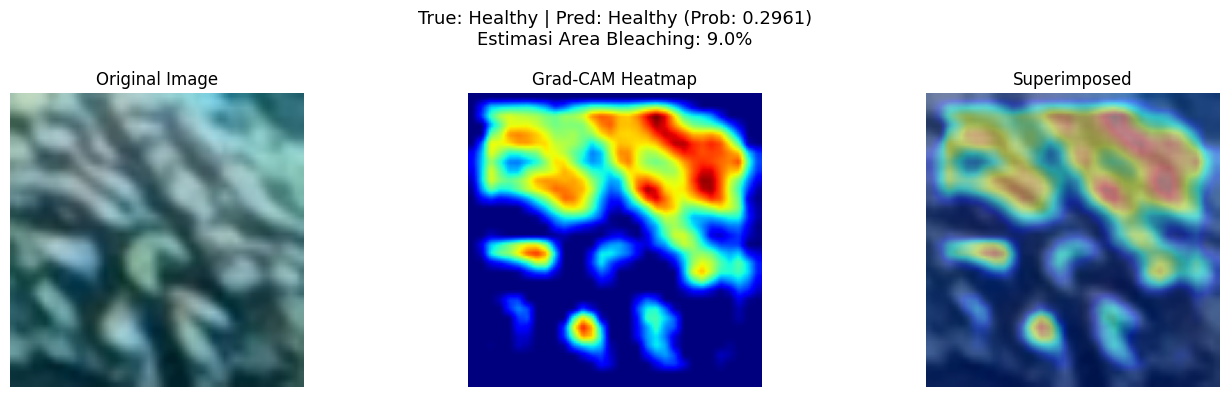

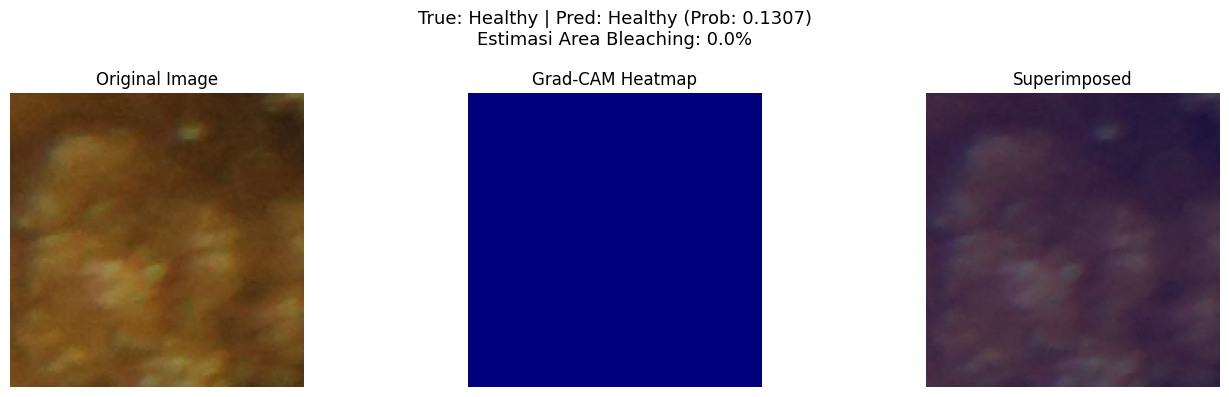

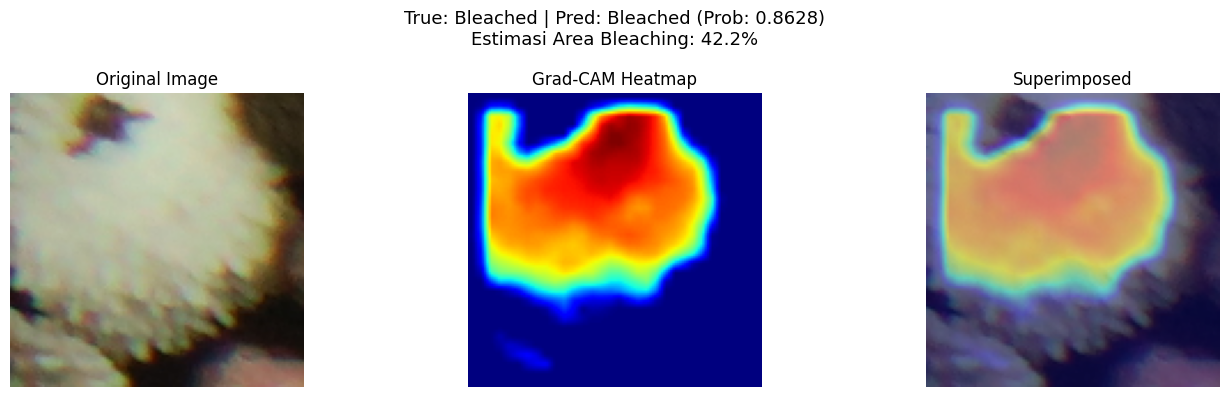

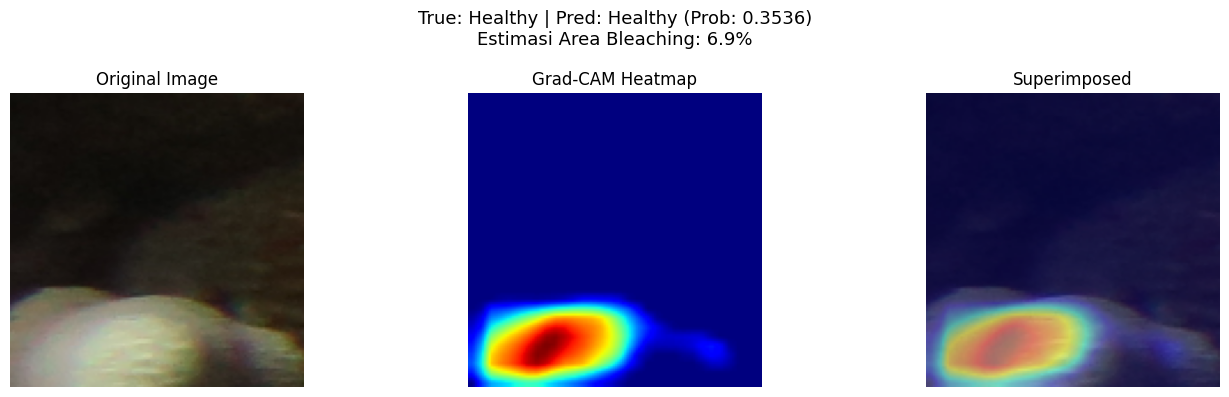

In [126]:
# Test
import random
for _ in range(4):
    random_idx = random.randint(0, len(X_test_final) - 1)
    visualize_gradcam_with_percentage(random_idx)

In [127]:
# Cek distribusi prediksi di seluruh test set
import numpy as np
y_pred_all = cnn_model.predict(X_test_final.astype('float32'), verbose=0)
print("Min prob:", y_pred_all.min())
print("Max prob:", y_pred_all.max())
print("Mean prob:", y_pred_all.mean())
print("Pred > 0.5:", (y_pred_all > 0.5).sum(), "dari", len(y_pred_all))

# Cek distribusi label test
unique, counts = np.unique(y_test_final, return_counts=True)
print("Label distribution:", dict(zip(unique, counts)))

Min prob: 0.0021840264
Max prob: 0.9989372
Mean prob: 0.47136804
Pred > 0.5: 907 dari 2251
Label distribution: {np.float32(0.0): np.int64(1374), np.float32(1.0): np.int64(877)}


Simpan Model ke Google Drive

In [128]:
save_dir = "/content/drive/MyDrive/[Penulisan Ilmiah]"
os.makedirs(save_dir, exist_ok=True)

# Simpan model
model_path = os.path.join(save_dir, "cnn_coral_bleaching_(new).keras")
cnn_model.save(model_path)

print(f"Model berhasil disimpan di: {model_path}")

Model berhasil disimpan di: /content/drive/MyDrive/[Penulisan Ilmiah]/cnn_coral_bleaching_(new).keras
